# LCM Training Monitor

This notebook provides tools to monitor the training progress of the LCM model and perform inference.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

## Training Metrics Visualization

In [2]:
def load_metrics(csv_path: str) -> pd.DataFrame:
    """Load training metrics from CSV file."""
    metrics_df = pd.read_csv(csv_path)
    metrics_df["lr-AdamW"] = metrics_df["lr-AdamW"].ffill()

    metrics_df = metrics_df[metrics_df["train_loss"].notna() + metrics_df["val_loss"].notna()]
    metrics_df = metrics_df.groupby("epoch").mean()

    metrics_df = metrics_df.reset_index()

    return metrics_df

In [3]:
def plot_metrics(metrics_df: pd.DataFrame) -> None:
    """Plot training metrics."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(metrics_df["epoch"], metrics_df["train_loss"], label="Train Loss")
    ax1.plot(metrics_df["epoch"], metrics_df["val_loss"], label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_ylim(0.00, 0.8)
    ax1.set_title("Training and Validation Loss")
    ax1.legend()
    ax1.grid(True)

    # Plot learning rate
    ax2.plot(metrics_df["epoch"], metrics_df["lr-AdamW"], label="Learning Rate")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Learning Rate Schedule")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

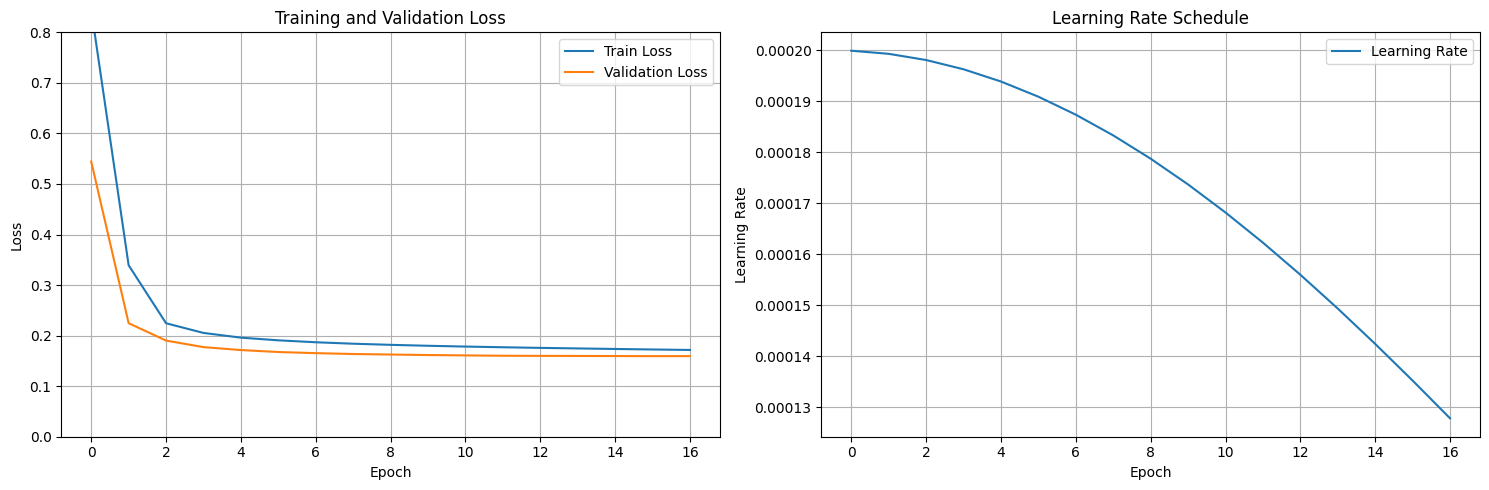

In [39]:
metrics_path = "/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/lightning_logs/version_117/metrics.csv"
metrics_df = load_metrics(metrics_path)

plot_metrics(metrics_df)

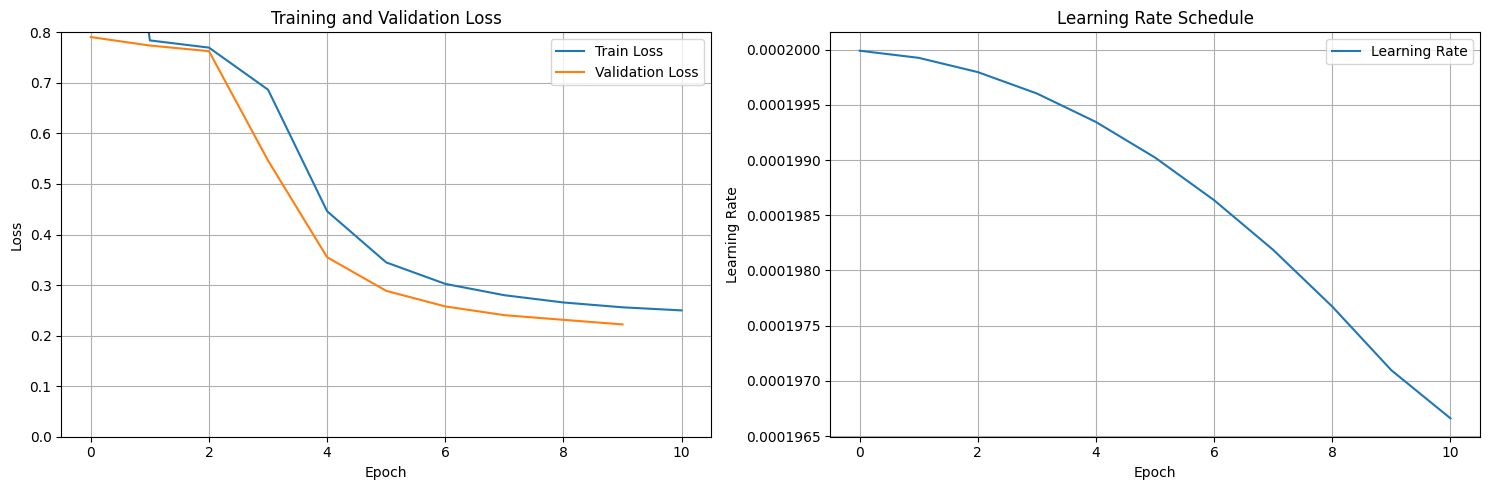

In [9]:
metrics_path = "/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/lightning_logs/version_107/metrics.csv"
metrics_df = load_metrics(metrics_path)

plot_metrics(metrics_df)

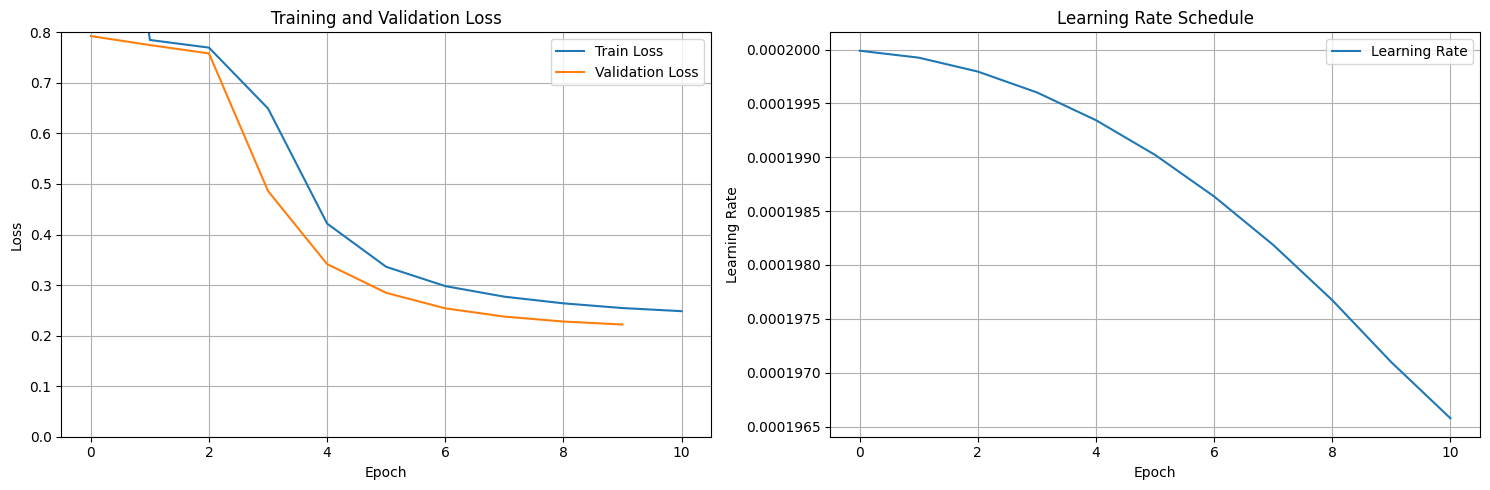

In [333]:
metrics_path = "/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/lightning_logs/version_108/metrics.csv"
metrics_df = load_metrics(metrics_path)

plot_metrics(metrics_df)

## Model Inference

This section allows you to load a trained model and perform inference on new text.

In [5]:
from lcm_explo.adapters.embedding_repository.file_system import FileSystemEmbeddingRepository
from lcm_explo.domain.models.base_lcm import BaseLCM, BaseLCMConfig
from lcm_explo.domain.usecases.train import BaseLCMTrainingModule

In [6]:
def generate_next_concepts(model: BaseLCM, input_embeddings: torch.Tensor, num_steps: int = 10) -> torch.Tensor:
    """Generate next concepts using the model."""
    device = next(model.parameters()).device

    # Move input to same device as model
    input_embeddings = input_embeddings.to(device)

    # Generate next concepts
    with torch.no_grad():
        current_sequence = input_embeddings
        generated_sequence = [current_sequence]

        for _ in range(num_steps):
            # Get next concept prediction
            padding_mask = torch.ones(current_sequence.shape[0]).to(device)
            next_concept = model(current_sequence, padding_mask)

            # Update sequence
            current_sequence = torch.cat([current_sequence[:, 1:], next_concept[:, -1:]], dim=1)
            generated_sequence.append(next_concept[:, -1:])

    return torch.cat(generated_sequence, dim=1)

In [130]:
checkpoint_path = "data/checkpoints/lcm-epoch=15-val_loss=0.1594.ckpt"
config = BaseLCMConfig(
    max_seq_len=32
)
model = BaseLCMTrainingModule.load_from_checkpoint(
    checkpoint_path,
).eval()

In [10]:
from transformers import NllbTokenizer

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf").to("mps")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

In [28]:
from lcm_explo.adapters.dataset.embedding import EmbeddingsDataset
from pathlib import Path
import random 
import numpy as np

def set_random_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(42)

dataset = EmbeddingsDataset(embeddings_dir=Path("./data"), sequence_length=32)
train_docs = int(0.9 * len(dataset.documents))

val_documents = dataset.documents[train_docs:]
val_sequence_indices = [idx for idx in dataset.sequence_indices if idx[0] in val_documents]
val_dataset = torch.utils.data.Subset(dataset, [dataset.sequence_indices.index(idx) for idx in val_sequence_indices])

In [122]:
input_embeddings, target_embeddings, padding_mask = val_dataset[7680]

next_concept = input_embeddings.unsqueeze(0).to("mps")

for _ in range(10):
    next_concept = model(next_concept, padding_mask.unsqueeze(0).to("mps"))

In [123]:
i = 31

In [124]:
next_concept[0][i]

tensor([ 4.5825e-04, -1.5307e-03, -3.2062e-03,  ..., -1.9725e-05,
        -5.7135e-03,  8.1749e-03], device='mps:0', grad_fn=<SelectBackward0>)

In [125]:
target_embeddings[i]

tensor([ 0.0035, -0.0034, -0.0004,  ...,  0.0009,  0.0009,  0.0051],
       device='mps:0')

In [126]:
# input_embeddings[i+1]

In [127]:
from torch import nn

mse = nn.MSELoss(reduction="none")

mse_loss = mse(next_concept, target_embeddings.unsqueeze(0)).mean(dim=-1)
masked_mse_loss = mse_loss * padding_mask.to("mps")

mean_masked_mse_loss = masked_mse_loss.sum() / padding_mask.to("mps").sum()

loss = torch.sqrt(mean_masked_mse_loss + 1e-6) * 100

loss

tensor(0.7093, device='mps:0', grad_fn=<MulBackward0>)

In [128]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

all_text = []

t = input_embeddings.unsqueeze(0)

for i in range(t.shape[1]):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=t[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    all_text.append(text_out[0])
    print(text_out[0])
    

diatomic carbon dicarbon ().
When excited, this gas glows green.
Occurrence Carbon is the fourth most abundant chemical element in the
observable universe by mass after hydrogen, helium, and oxygen.
Carbon is abundant in the Sun, stars, comets, and in the atmospheres
most planets.
Some meteorites contain microscopic diamonds that were formed when the
Solar System was still a protoplanetary disk.
Microscopic diamonds may also be formed by the intense pressure and high
temperature at the sites of meteorite impacts.
In 2014 NASA announced a greatly upgraded database for tracking polycyclic
aromatic hydrocarbons (PAHs) in the universe.
More than 20% of the carbon in the universe may be associated with PAHs,
complex compounds of carbon and hydrogen without oxygen.
These compounds figure in the PAH world hypothesis where they are
hypothesized to have a role in abiogenesis and formation of life.
PAHs appear to have formed "a couple of billion years" after the Big
Bang, are widespread througho

In [129]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

all_text = []

for i in range(next_concept.shape[1]):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=next_concept[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    all_text.append(text_out[0])
    print(text_out[0])
    

In 2014 NASA announced a highly improved database for tracking polycyclic
aromatic hydrocarbons (PAHs) in the universe.
More than 20% of the carbon in the universe may be associated with PAHs,
complex compounds of carbon and hydrogen without oxygen.
These compounds figure in the PAH world hypothesis, where they are
hypothesized to have a role in abiogenesis and formation of life.
PAHs appear to have formed "a couple of billion years" after the Big
Bang, are widespread throughout the universe, and are associated with new
stars and exoplanets.
It has been estimated that the solid earth as a whole contains 730 ppm of
carbon, with 2 ppm in the core, and 120 ppm in the combined mant
crust.
Since the mass of the earth is , this would imply 4360 million gigatons
of carbon.
This is much more than the amount of carbon in the oceans or the atmosphere
(below).
In combination with oxygen in carbon dioxide, carbon is found in the
Earth's atmosphere (approximately 900 gigatons of carbon  every ppm
c

In [16]:
from transformers import NllbTokenizer

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf").to("mps")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

In [59]:
# Load some example embeddings
embeddings_repo = FileSystemEmbeddingRepository(base_path="data")
example_doc = embeddings_repo.load_document_embeddings("...Baby One More Time (album)")

# Generate next concepts
input_embeddings_part = example_doc.embeddings[:32].unsqueeze(0)  # Add batch dimension
input_padding = torch.zeros(
    (32 - input_embeddings_part.shape[1], input_embeddings_part.shape[2]), device=input_embeddings_part.device
)
input_embeddings = torch.cat([input_embeddings_part, input_padding.unsqueeze(0)], dim=1)
padding_mask = torch.cat([torch.ones((1, input_embeddings_part.shape[1])), torch.zeros((1, input_padding.shape[0]))], dim=1)
generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=20)

print(f"Generated sequence shape: {generated_sequence.shape}")

Generated sequence shape: torch.Size([1, 52, 1024])


In [29]:
padding_mask.shape

torch.Size([1, 32])

In [60]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

all_text = []

for i in range(generated_sequence.shape[1]):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    all_text.append(text_out[0])
    print(text_out[0])
    
#print(all_text)

...Baby One More Time is the debut studio album by American singer Britney
Spears.
It was released on January 12, 1999, by Jive Records.
Spears had been a child performer on The All-New Mickey Mouse Club from
1993 to 1994, and was looking to expand her career as a teen singer.
After being turned down by several record companies, Spears signed with
Jive for a multi-album deal in 1997.
She traveled to Sweden to collaborate with producers Max Martin and Rami
Yacoub, who had been writing songs with producer Denniz Pop and others,
for ...
Baby One More Time.
Their collaboration created a pop, bubblegum pop, dance-pop, and teen pop
record, with Spears later saying that she felt excited when she heard it
and knew it was going to be a hit record.
The album was completed in June 1998.
Upon its release, ...
Baby One More Time garnered mixed reviews from music critics, with many
praising its commercial appeal but considering it silly and premature.
Despite its initial mixed reception, it helped S

In [31]:
all_text[-11]

'It has been certified 14× platinum (diamond) by the Recording Industry'

In [57]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

input_embeddings_part = example_doc.embeddings[:52].unsqueeze(0)  # Add batch dimension

all_text = []

for i in range(input_embeddings_part.shape[1]):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=input_embeddings_part[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    all_text.append(text_out[0])
    print(text_out[0])
    
#print(all_text)

...Baby One More Time is the debut studio album by American singer Britney
Spears.
It was released on January 12, 1999, by Jive Records.
Spears had been a child performer on The All-New Mickey Mouse Club from
1993 to 1994, and was looking to expand her career as a teen singer.
After being turned down by several record companies, Spears signed with
Jive for a multi-album deal in 1997.
She traveled to Sweden to collaborate with producers Max Martin and Rami
Yacoub, who had been writing songs with producer Denniz Pop and others,
for ...
Baby One More Time.
Their collaboration created a pop, bubblegum pop, dance-pop, and teen pop
record, with Spears later saying that she felt excited when she heard it
and knew it was going to be a hit record.
The album was completed in June 1998.
Upon its release, ...
Baby One More Time garnered mixed reviews from music critics, with many
praising its commercial appeal but considering it silly and premature.
Despite its initial mixed reception, it helped S

In [34]:
from transformers import NllbTokenizer
from wtpsplit import SaT

from lcm_explo.domain.usecases.encode import encode_text_sonar_with_spacy
from lcm_explo.m2m_100 import M2M100EncoderModel

sonar_encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf").to("mps")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

In [37]:
embeddings.shape

torch.Size([21, 1024])

In [40]:
from lcm_explo.domain.usecases.encode import encode_text_sonar_with_spacy
my_text = """
My name is Yann HALLOUARD, I 'm a data Scientist at TotalEnergies DIgital Factory ! I'm 29 years old. 
Turning Personal Challenges into Tech Solutions
Two years ago, living with Crohn’s disease, I found myself drowning in paper blood test results. Tracking trends over years? Nearly impossible. That’s when I dreamed of building a simple app to digitize this process. But back then, my choice of Streamlit led to dead ends—hard to scale, confined to my laptop. Fast forward to today: with two years of growth at TotalEnergies Digital Factory under my belt, I revisited the idea during a 4-day weekend (yes, I even had time to march for Labor Day – multitasking at its finest!) and created Héméa.
Why Héméa?
Data stays ONLY on your phone—no clouds, no third-party storage. Privacy first!
Open-source code available on GitHub for full transparency.
Note on data extraction: Uses Mistral’s API for text analysis, but your raw data never leaves your device.
Current Status: It’s alive on my phone! But here’s the catch: I’m launching it freely on Google Play Store soon. As for the AppStore? Well, $100/year just to list an app feels steep for a passion project. But if enough of you show interest (slide into my DMs!), I’ll gladly take the leap.
This journey isn’t just about tech—it’s about turning frustration into purpose. To everyone battling invisible battles: keep creating, keep pushing.
PS: Crohn’s warriors, I see you. Let’s connect and share stories.
""" 

embeddings = encode_text_sonar_with_spacy(
    my_text,
    device="mps",
    sonar_tokenizer=sonar_tokenizer,
    sonar_model=sonar_encoder,
)

input_embeddings = embeddings.unsqueeze(0)
my_generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=10)

print(f"Generated sequence shape: {my_generated_sequence.shape}")

Generated sequence shape: torch.Size([1, 42, 1024])


In [41]:
from transformers.modeling_outputs import BaseModelOutput

def split_long_text(tokenizer, splitter, text: str, max_length: int = 1024) -> list[str]:
    splits = splitter.split(text)
    splits = [split for split in splits if split.replace(" ", "") != "" and len(split) > 10]
    return splits


refined_text = my_text.replace("sent", ". sent")


embeddings = []
with torch.no_grad():
    chunks = split_long_text(sonar_tokenizer, splitter, refined_text)
    for chunk in chunks:
        inputs = sonar_tokenizer(chunk, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
        outputs = sonar_encoder(**inputs)
        embeddings.append(outputs.last_hidden_state.mean(dim=1))

out = torch.vstack(embeddings)

generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=out.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
text_out

NameError: name 'splitter' is not defined

In [33]:
chunks

['Its position appears to shift relative to the horizon.',
 'Based on the context, we can infer the hypothesis: the earth rotating on its axis causes stars to move relative to the horizon during the night',
 'Reasoning chain: ',
 'sent11 & . ',
 "int1: apparent motion of stars is when stars appear to move relative to earth's position; ",
 'int2: the earth rotating on its axis causes apparent motion of stars; ',
 'sent23 -> hypothesis;',
 'Proof: [BECAUSE] ',
 'a star is a kind of celestial object / celestial body [AND] ',
 "apparent motion is when an object appears to move relative to another object 's position [AND] ",
 'earth is a kind of celestial object [INFER] ',
 "int1: apparent motion of stars is when stars appear to move relative to earth's position [BECAUSE] ",
 'int1 [AND] ',
 'the earth rotating on its axis causes stars to appear to move across the sky at night [INFER] ',
 'int2: the earth rotating on its axis causes apparent motion of stars [BECAUSE] ',
 'int2 [AND] ',
 'st

In [42]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

my_all_text = []

for i in tqdm(range(my_generated_sequence.shape[1])):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=my_generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    my_all_text.append(text_out[0])
print(my_all_text)

100%|████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:28<00:00,  1.49it/s]

['2', 'My name is Yann HALLOUARD, I am a data scientist at Total', 'Factory !', "I'm 29 years old.", 'Turning Personal Challenges into Tech Solutions Two years ago, living with', "Crohn's disease, I found myself drowning in paper blood test results.", 'Tracking trends over years?', 'Almost impossible.', "That's when I dreamed of building an simple app to digitise this process.", 'But then, my choice of Streamlit led to dead ends.Hard to scale,', 'confined to my laptop.', 'Fast forward to today: with two years of growth at TotalEnergies Digital', 'Factory under my belt, I revisited the idea during a 4-day weekend (yes,', 'had even time to march for Labor Day  multitasking at its finest!) and', 'created Héméa.', 'Why Héméa? Data Stay only on your phone? No clouds, no third party', 'storage.', 'Privacy first!', 'Open-source code available on GitHub for full transparency.', "Note on data extraction: Uses Mistral's API for text analysis, but", 'raw data never leaves your device.', "Current 